# MDR-TD v1.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Yicheng (Roy) Pan  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Notebook Type:** Training & Evaluation  
**Last Updated:** May 26, 2026

---

## Model Summary
- **Model Name:** MDR-TD
- **Version:** v1.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** delta of `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Jupyter Lab + VS Code

---

**What's new?**
- Hyperparameters tuning from v1.0

In [1]:
import os
import sys
import random
from pathlib import Path
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import torch


PROJECT_ROOT = os.path.abspath("../")
print(f"project_root: {PROJECT_ROOT}")
if PROJECT_ROOT not in sys.path:
    # sys.path.insert(0, PROJECT_ROOT)
    sys.path.append(PROJECT_ROOT)

try:
    from Models.Utils.dashboard import metrics_dashboard
    print("Imported dashboard from Models.Utils")
except ImportError as e:
    from Utils.dashboard import metrics_dashboard
    print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"torch using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def _gpu_available():
    try:
        import subprocess
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except Exception:
        return False

HAS_GPU = _gpu_available()

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print(f"  GPU available: {HAS_GPU}")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

project_root: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from Models.Utils
imports loaded
torch using: cpu
Random seed set to 42
Environment information:
  Python version: 3.12.8
  NumPy version:  2.4.4
  Pandas version: 3.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: True
environment setup complete


In [2]:
VERSION    = "v1"
SUBVERSION = "v1.1"
RUN_NAME   = "mdr_td_v1_1"

DATA_ROOT    = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT   = f"{DATA_ROOT}/splits"
OUTPUT_ROOT  = f"{PROJECT_ROOT}/Models/TemporalDelta/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",   os.path.exists(DATA_ROOT))
print("  splits exists:", os.path.exists(SPLIT_ROOT))
print("  output exists:", os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: C:\Users\pan\Documents\GitHub\MDR-Project
  DATA_ROOT:    C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data
  SPLIT_ROOT:   C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  C:\Users\pan\Documents\GitHub\MDR-Project/Models/TemporalDelta/v1/v1.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [3]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\train.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\val.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\test.csv


## Features

In [4]:
TARGET_COL = "soil_moisture_5cm"
TARGET_DELTA_COL = "delta_soil_moisture_5cm"
Y_LAG1_COL = "soil_moisture_5cm_lag1"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0',
    'soil_moisture_5cm_lag1'
]

In [5]:
# Create delta target (day-over-day first difference)
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values(["station_id", "date"], inplace=True)
    df[Y_LAG1_COL] = df.groupby("station_id")[TARGET_COL].shift(1)
    df[TARGET_DELTA_COL] = df[TARGET_COL] - df[Y_LAG1_COL]
    df.dropna(subset=[TARGET_DELTA_COL], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"train rows after delta: {len(train_df)}")
print(f"val   rows after delta: {len(val_df)}")
print(f"test  rows after delta: {len(test_df)}")

train rows after delta: 6863
val   rows after delta: 2716
test  rows after delta: 4011


## Utils

In [6]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

def get_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 15

def plot_top_features(model, feature_cols, title):
    imp = get_importance(model, feature_cols)
    imp_top = imp.sort_values(ascending=False).head(TOP_K)

    print(f"\n{title} - Top {TOP_K} Features")
    print("=" * 50)
    print(imp_top.to_string())

    plt.figure(figsize=(6, max(4, 0.4 * TOP_K)))
    y = np.arange(len(imp_top))

    plt.barh(y, imp_top.values)
    plt.yticks(y, imp_top.index)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

### Split

In [7]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6863
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-02 00:00:00 -- 2020-12-31 00:00:00

VAL
  rows:     2716
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-02 00:00:00 -- 2022-12-31 00:00:00

TEST
  rows:     4011
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-02 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## Train

In [8]:
# --- Filter features present in data ---
available_features = [c for c in FEATURE_COLS if c in train_df.columns]
missing = set(FEATURE_COLS) - set(train_df.columns)
if missing:
    print(f"Warning: {len(missing)} features not found: {missing}")

# --- Prepare X/y for delta prediction ---
X_train = train_df[available_features]
y_train_delta = train_df[TARGET_DELTA_COL]
y_train_lag1 = train_df[Y_LAG1_COL]

X_val = val_df[available_features]
y_val_delta = val_df[TARGET_DELTA_COL]
y_val_lag1 = val_df[Y_LAG1_COL]

X_test = test_df[available_features]
y_test_delta = test_df[TARGET_DELTA_COL]
y_test_lag1 = test_df[Y_LAG1_COL]

print(f"Train: X {X_train.shape}, y_delta {y_train_delta.shape}")
print(f"Val:   X {X_val.shape}, y_delta {y_val_delta.shape}")
print(f"Test:  X {X_test.shape}, y_delta {y_test_delta.shape}")

Train: X (6863, 38), y_delta (6863,)
Val:   X (2716, 38), y_delta (2716,)
Test:  X (4011, 38), y_delta (4011,)


In [ ]:
RF_PARAMS = dict(
    n_estimators=800, 
    max_depth=None, 
    min_samples_split=4,
    min_samples_leaf=2, 
    max_features="sqrt", 
    random_state=SEED, 
    n_jobs=-1,
)

t0 = time.time()
rf_model = RandomForestRegressor(**RF_PARAMS)
rf_model.fit(X_train, y_train_delta)
t1 = time.time()
print(f"RF trained in {t1-t0:.1f}s")

RF trained in 2.4s


In [14]:
# --- Hyperparameter grid search for RandomForestRegressor ---
GRID = [
    dict(n_estimators=400,  max_depth=None, min_samples_split=4, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=4, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=1200, max_depth=None, min_samples_split=4, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=20,   min_samples_split=4, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=10,   min_samples_split=4, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=6, min_samples_leaf=1, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=4, min_samples_leaf=2, max_features="sqrt"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=4, min_samples_leaf=1, max_features="log2"),
    dict(n_estimators=800,  max_depth=None, min_samples_split=4, min_samples_leaf=1, max_features=1.0),
]

rows = []

for i, params in enumerate(GRID):
    print(f"\n[{i+1}/{len(GRID)}] n_est={params['n_estimators']}, depth={params['max_depth']}, split={params['min_samples_split']}, leaf={params['min_samples_leaf']}, mf={params['max_features']}")
    t0 = time.time()
    rf = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, y_train_delta)
    t1 = time.time()
    print(f"  trained in {t1-t0:.1f}s")

    vdp = rf.predict(X_val)
    tdp = rf.predict(X_test)

    vdr2 = r2_score(y_val_delta, vdp)
    tdr2 = r2_score(y_test_delta, tdp)

    vrr2 = r2_score(val_df[TARGET_COL], y_val_lag1 + vdp)
    trr2 = r2_score(test_df[TARGET_COL], y_test_lag1 + tdp)

    print(f"  Val \u0394SM R\u00b2={vdr2:.4f} | Test \u0394SM R\u00b2={tdr2:.4f}")
    print(f"  Val Recon R\u00b2={vrr2:.4f} | Test Recon R\u00b2={trr2:.4f}")

    rows.append({**params, 'val_delta_r2': vdr2, 'test_delta_r2': tdr2, 'val_recon_r2': vrr2, 'test_recon_r2': trr2})

results_df = pd.DataFrame(rows)
results_df.to_csv(f"{OUTPUT_ROOT}/hyperparameter_tuning.csv", index=False)

print("\n\n=== GRID SEARCH RESULTS ===")
print("|n_estimators|max_depth|min_samples_split|min_samples_leaf|max_features|Val \u0394SM R^2|Test \u0394SM R^2|Val Recon SM R^2|Test Recon SM R^2|")
print("|---|---|---|---|---|---|---|---|---|")
for r in rows:
    print(f"|{r['n_estimators']}|{r['max_depth']}|{r['min_samples_split']}|{r['min_samples_leaf']}|{r['max_features']}|{r['val_delta_r2']:.4f}|{r['test_delta_r2']:.4f}|{r['val_recon_r2']:.4f}|{r['test_recon_r2']:.4f}|")

best = max(rows, key=lambda r: r['val_delta_r2'])
print(f"\nBest config by Val \u0394SM R\u00b2 ({best['val_delta_r2']:.4f}):")
print(f"  n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, min_samples_split={best['min_samples_split']}, min_samples_leaf={best['min_samples_leaf']}, max_features={best['max_features']}")



[1/10] n_est=400, depth=None, split=4, leaf=1, mf=sqrt
  trained in 1.2s
  Val ΔSM R²=0.2748 | Test ΔSM R²=0.2606
  Val Recon R²=0.9856 | Test Recon R²=0.9789

[2/10] n_est=800, depth=None, split=4, leaf=1, mf=sqrt
  trained in 2.5s
  Val ΔSM R²=0.2774 | Test ΔSM R²=0.2639
  Val Recon R²=0.9857 | Test Recon R²=0.9790

[3/10] n_est=1200, depth=None, split=4, leaf=1, mf=sqrt
  trained in 3.7s
  Val ΔSM R²=0.2770 | Test ΔSM R²=0.2612
  Val Recon R²=0.9857 | Test Recon R²=0.9789

[4/10] n_est=800, depth=20, split=4, leaf=1, mf=sqrt
  trained in 2.3s
  Val ΔSM R²=0.2781 | Test ΔSM R²=0.2597
  Val Recon R²=0.9857 | Test Recon R²=0.9789

[5/10] n_est=800, depth=10, split=4, leaf=1, mf=sqrt
  trained in 1.5s
  Val ΔSM R²=0.2452 | Test ΔSM R²=0.2410
  Val Recon R²=0.9851 | Test Recon R²=0.9784

[6/10] n_est=800, depth=None, split=2, leaf=1, mf=sqrt
  trained in 2.6s
  Val ΔSM R²=0.2795 | Test ΔSM R²=0.2608
  Val Recon R²=0.9857 | Test Recon R²=0.9789

[7/10] n_est=800, depth=None, split=6, lea

### Hyperparameters Tuning
|n_estimators|max_depth|min_samples_split|min_samples_leaf|max_features|Val ΔSM R^2|Test ΔSM R^2|Val Recon SM R^2|Test Recon SM R^2|
|---|---|---|---|---|---|---|---|---|
|400|None|4|1|sqrt|0.2748|0.2606|0.9856|0.9789|
|800|None|4|1|sqrt|0.2774|0.2639|0.9857|0.9790|
|1200|None|4|1|sqrt|0.2770|0.2612|0.9857|0.9789|
|800|20|4|1|sqrt|0.2781|0.2597|0.9857|0.9789|
|800|10|4|1|sqrt|0.2452|0.2410|0.9851|0.9784|
|800|None|2|1|sqrt|0.2795|0.2608|0.9857|0.9789|
|800|None|6|1|sqrt|0.2776|0.2606|0.9857|0.9789|
|800|None|4|2|sqrt|**0.2836**|**0.2702**|**0.9858**|**0.9792**|
|800|None|4|1|log2|0.2707|0.2593|0.9856|0.9789|
|800|None|4|1|1.0|0.2497|0.2572|0.9851|0.9788|

**Best: n_estimators=800, max_depth=None, min_samples_split=4, min_samples_leaf=2, max_features=sqrt**


## Evaluate

In [10]:
# --- Predict delta ---
y_val_delta_pred = rf_model.predict(X_val)
y_test_delta_pred = rf_model.predict(X_test)

# --- Delta metrics ---
val_delta_metrics = get_metrics_dict(y_val_delta, y_val_delta_pred, prefix="val_delta_")
neat_print(val_delta_metrics, title="VAL \u2014 Delta SM")
metrics_dashboard(y_val_delta, y_val_delta_pred, name="Val \u0394SM")

test_delta_metrics = get_metrics_dict(y_test_delta, y_test_delta_pred, prefix="test_delta_")
neat_print(test_delta_metrics, title="TEST \u2014 Delta SM")
metrics_dashboard(y_test_delta, y_test_delta_pred, name="Test \u0394SM")

# --- Reconstruct raw SM (one-step) ---
y_val_recon = y_val_lag1.to_numpy().ravel() + y_val_delta_pred.ravel()
y_test_recon = y_test_lag1.to_numpy().ravel() + y_test_delta_pred.ravel()
y_val_true = val_df[TARGET_COL].to_numpy().ravel()
y_test_true = test_df[TARGET_COL].to_numpy().ravel()

val_recon_metrics = get_metrics_dict(y_val_true, y_val_recon, prefix="val_recon_")
neat_print(val_recon_metrics, title="VAL \u2014 Reconstructed SM")
metrics_dashboard(y_val_true, y_val_recon, name="Val Reconstructed SM")

test_recon_metrics = get_metrics_dict(y_test_true, y_test_recon, prefix="test_recon_")
neat_print(test_recon_metrics, title="TEST \u2014 Reconstructed SM")
metrics_dashboard(y_test_true, y_test_recon, name="Test Reconstructed SM")


VAL — Delta SM
Metric                          Value
------------------------------------------
val_delta_n                     2,716
val_delta_r2                  0.27740
val_delta_mae                 0.00765
val_delta_rmse                0.01257
val_delta_ubrmse              0.01255
val_delta_bias               -0.00074
val_delta_med_ae              0.00416
val_delta_p90_ae              0.01938
val_delta_q05_err            -0.01863
val_delta_q50_err            -0.00091
val_delta_q95_err             0.02096



TEST — Delta SM
Metric                          Value
------------------------------------------
test_delta_n                    4,011
test_delta_r2                 0.26394
test_delta_mae                0.00808
test_delta_rmse               0.01364
test_delta_ubrmse             0.01350
test_delta_bias              -0.00198
test_delta_med_ae             0.00452
test_delta_p90_ae             0.01965
test_delta_q05_err           -0.02025
test_delta_q50_err           -0.00195
test_delta_q95_err            0.01894



VAL — Reconstructed SM
Metric                          Value
------------------------------------------
val_recon_n                     2,716
val_recon_r2                  0.98569
val_recon_mae                 0.00765
val_recon_rmse                0.01257
val_recon_ubrmse              0.01255
val_recon_bias               -0.00074
val_recon_med_ae              0.00416
val_recon_p90_ae              0.01938
val_recon_q05_err            -0.01863
val_recon_q50_err            -0.00091
val_recon_q95_err             0.02096



TEST — Reconstructed SM
Metric                          Value
------------------------------------------
test_recon_n                    4,011
test_recon_r2                 0.97901
test_recon_mae                0.00808
test_recon_rmse               0.01364
test_recon_ubrmse             0.01350
test_recon_bias              -0.00198
test_recon_med_ae             0.00452
test_recon_p90_ae             0.01965
test_recon_q05_err           -0.02025
test_recon_q50_err           -0.00195
test_recon_q95_err            0.01894


## Feature Importance


RF ΔSM Feature Importance - Top 15 Features
soil_moisture_5cm_lag1     0.073966
G_rain_sum_3d              0.063697
C_lag_G_API_kobs1          0.053747
G_DSLR                     0.053441
G_API                      0.044623
API_x_year                 0.041541
G_rain_sum_7d              0.039210
V_rollmean_G_API_kobs7     0.038483
V_ema_G_API_kobs30         0.035808
V_rollmean_s2_b11_kobs7    0.035307
V_ema_LST_modis_kobs7      0.035093
D_sin_DOY                  0.035012
V_rollmean_G_API_kobs14    0.034387
V_ema_G_API_kobs14         0.034116
SMAP_sm_pm_interp_ema02    0.029958


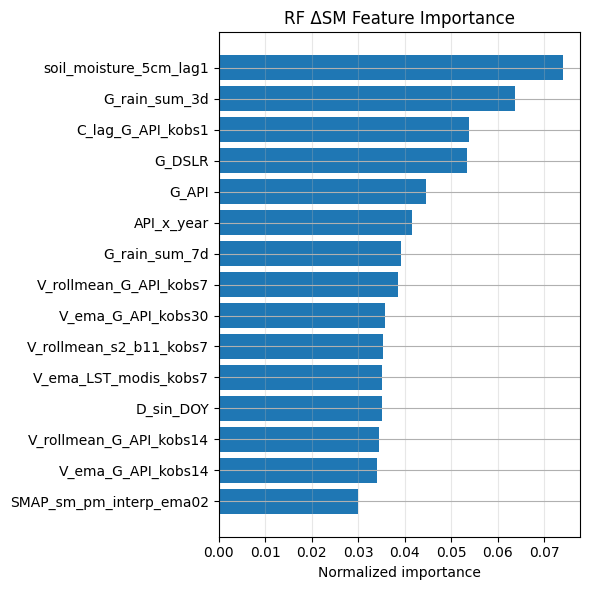

In [11]:
plot_top_features(rf_model, available_features, "RF ΔSM Feature Importance")